In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor

In [ ]:
data = pd.read_csv("onion_price_data.csv")

data["Arrival_Date"] = pd.to_datetime(
    data["Arrival_Date"], dayfirst=True, errors="coerce"
)
data.sort_values("Arrival_Date", inplace=True)

In [ ]:
q1 = data["Modal_Price"].quantile(0.25)
q3 = data["Modal_Price"].quantile(0.75)
iqr = q3 - q1

data = data[
    (data["Modal_Price"] >= q1 - 1.5 * iqr) &
    (data["Modal_Price"] <= q3 + 1.5 * iqr)
]


In [ ]:
# 3. Lag Features (VERY IMPORTANT)
# =========================
for lag in [1, 7, 14]:
    data[f"Modal_lag_{lag}"] = data["Modal_Price"].shift(lag)

data.dropna(inplace=True)

In [ ]:
# 4. Target & Features
# =========================
y = np.log1p(data["Modal_Price"])   # log transform
X = data.drop(columns=["Min_Price", "Max_Price", "Modal_Price"])

In [ ]:
# Date features
X["Day"] = X["Arrival_Date"].dt.day
X["Month"] = X["Arrival_Date"].dt.month
X["Year"] = X["Arrival_Date"].dt.year
X.drop(columns="Arrival_Date", inplace=True)

In [ ]:
split_year = X["Year"].quantile(0.8)

X_train = X[X["Year"] <= split_year]
X_test  = X[X["Year"] > split_year]

y_train = y.loc[X_train.index]
y_test  = y.loc[X_test.index]

In [ ]:

cat_cols = X.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough"
)

In [ ]:
# =========================
# 7. Models
# =========================
rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=400,
        max_depth=25,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
# =========================
# 8. Train Models
# =========================
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

In [ ]:
# =========================
# 9. Hybrid Prediction
# =========================
rf_pred = rf_model.predict(X_test).ravel()
xgb_pred = xgb_model.predict(X_test).ravel()
y_test_np = y_test.to_numpy().ravel()

hybrid_pred_log = 0.7 * rf_pred + 0.3 * xgb_pred

hybrid_pred = np.expm1(hybrid_pred_log)
y_test_actual = np.expm1(y_test_np)

In [ ]:
# =========================
# 10. Evaluation
# =========================
r2 = r2_score(y_test_actual, hybrid_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, hybrid_pred))

print("📊 MODAL PRICE MODEL PERFORMANCE")
print(f"R² Score : {r2:.3f}")
print(f"RMSE     : {rmse:.2f}")

print("\n🔎 SAMPLE PREDICTION")
print("Predicted :", round(hybrid_pred[0], 2))
print("Actual    :", round(y_test_actual[0], 2))

In [3]:
from sklearn.metrics import r2_score

accuracy = r2_score(y_test_actual, hybrid_pred, multioutput="uniform_average")

print(f"\nAccuracy (R²): {accuracy * 100:.2f}%")


Accuracy (R²): 91.97%


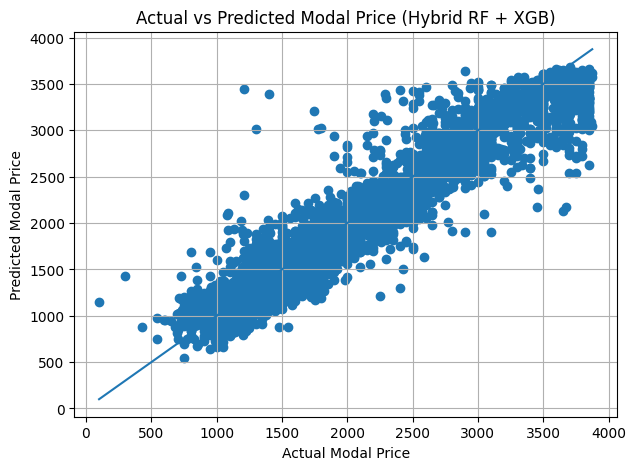

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test_actual, hybrid_pred)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()]
)

plt.xlabel("Actual Modal Price")
plt.ylabel("Predicted Modal Price")
plt.title("Actual vs Predicted Modal Price (Hybrid RF + XGB)")
plt.grid(True)

plt.show()


In [5]:
import joblib

joblib.dump(rf_model, "rf_modal_model.pkl")
joblib.dump(xgb_model, "xgb_modal_model.pkl")

print("✅ Models saved successfully")


✅ Models saved successfully
